<a href="https://colab.research.google.com/github/DanielaDSMS/Evidence-of-AI-related-skills/blob/main/Macaya_MP1MTB_rev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



>## Miniproyecto 1: 543816-1 MINERIA DE TEXTOS BIOMEDICOS (S1-2026)



Profesor(a): Rosa Figueroa

Ayudante: José Pinto

Estudiante: Daniela Macaya Suazo

#Ejercicio 1:
Carga y Exploración Inicial

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# a) Cargar el archivo csv
df = pd.read_csv('mental_heath_unbanlanced.csv')

# b) Explorar estructura
# a. Cantidad de filas y columnas
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")

# b. Presencia de valores nulos y eliminación
nulos = df.isnull().sum()
print("\nValores nulos por columna:")
print(nulos)

if nulos.sum() > 0:
    initial_rows = df.shape[0]
    df = df.dropna()
    rows_eliminated = initial_rows - df.shape[0]
    print(f"\nSe eliminaron los valores nulos. Nueva dimensión: {df.shape}")
    print(f"Filas eliminadas: {rows_eliminated}")
else:
    print("\nNo se encontraron valores nulos.")

# c. Cantidad de ejemplos por clase (status)
conteo_clases = df['status'].value_counts()
print("\nDistribución de ejemplos por clase:")
print(conteo_clases)

Dimensiones del dataset: 49612 filas y 3 columnas

Valores nulos por columna:
Unique_ID    9600
text            0
status          0
dtype: int64

Se eliminaron los valores nulos. Nueva dimensión: (40012, 3)
Filas eliminadas: 9600

Distribución de ejemplos por clase:
status
Normal        15991
Depression    12106
Suicidal       8812
Anxiety        3103
Name: count, dtype: int64


Visualización de la Distribución

/tmp/ipykernel_14655/1992215998.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='status', order=df['status'].value_counts().index, palette='pastel')


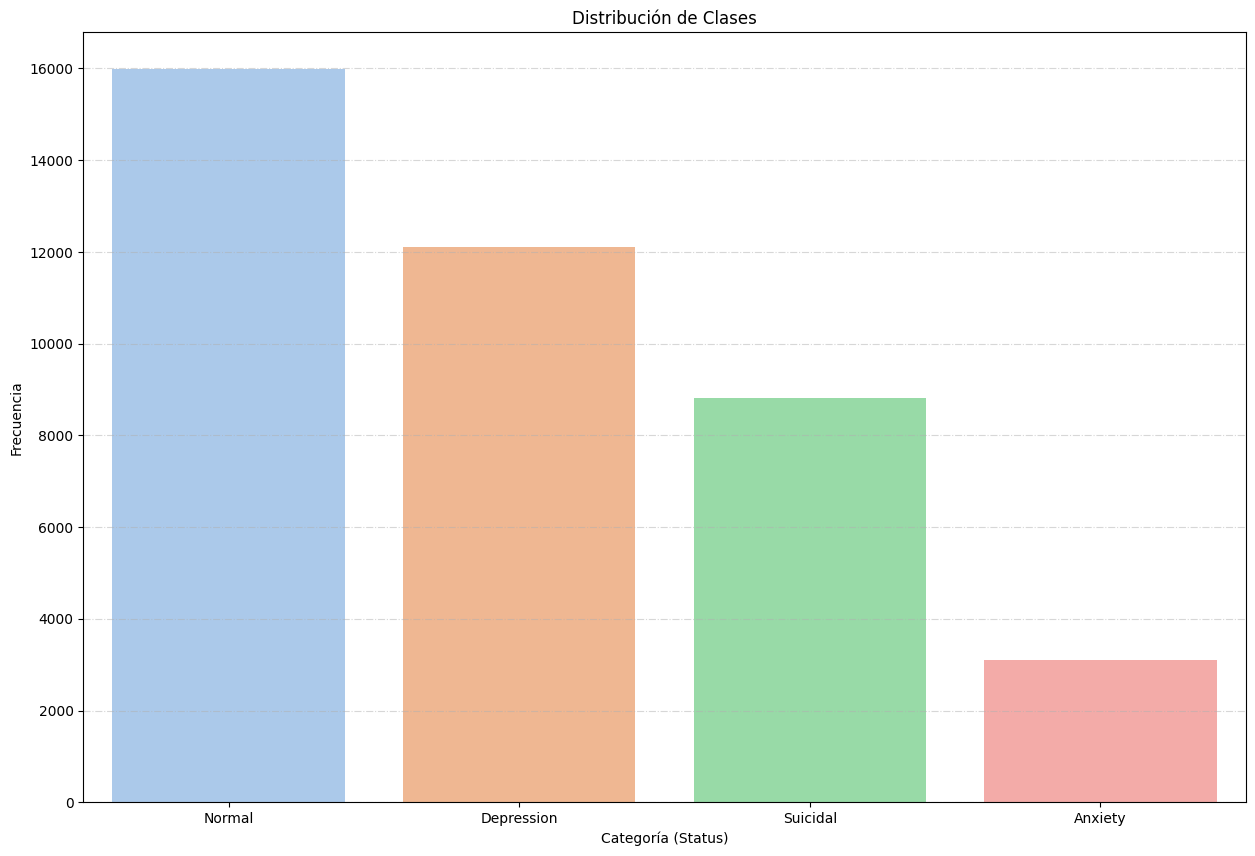

In [ ]:
# c) Analizar brevemente la distribución de la variable status
plt.figure(figsize=(15, 10))
sns.countplot(data=df, x='status', order=df['status'].value_counts().index, palette='pastel')
plt.title('Distribución de Clases')
plt.xlabel('Categoría (Status)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='-.', alpha=0.5)
plt.show()

## C) analisis de la variable status
se ve un desbalance, donde normal y depresion abarcan la mayoria del dataset. suicidal un punto medio, pero lo más preocupante es el de anxiety teniendo muy poca representación.

## d) comentar
# a. ¿El dataset está balanceado o desbalanceado?

El dataset está desbalanceado. Existe una diferencia notable entre la clase mayoritaria (Normal con 15991 registros) y la clase minoritaria (Anxiety con apenas 3103). La clase "Normal" tiene más de 5 veces la cantidad de datos que la clase "Anxiety".

#b. ¿Qué implicancias podría tener esto en futuros análisis o modelos?

Que si entrenas un modelo de clasificación, este tendrá una fuerte tendencia a predecir las clases más frecuentes ya sea Normal o Depression, porque tiene muchos más datos para aprender sus patrones. Y no tanta a Anxiety lo que dificultad en la Detección de Ansiedad al tener pocos datos de la clase Anxiety, el modelo podría tener un desempeño muy bajo (baja sensibilidad) para detectar correctamente a estos pacientes. Por ende el uso de la métrica de Accuracy no sería confiable.


## Comentario

Buen trabajo, solo una cosa: la columna ID es un identificador de los textos, la verdad no importa que está columna tenga valores nulos, de todas formas no se usa a la hora de construir los modelos. Por lo que no era necesario eliminar esos nulos de la columna. En este caso donde si es importante la existencia de nulos es en la columna de los textos o en status.

### Puntaje ej1: 0.8

##Ejercicio 2

In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# recursos necesarios
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) # El dataset completo es en inglés por lo que aplicamos este

def clean_text(text):
    # a) Convertir a minusculas
    text = text.lower()
    # b) Eliminar caracteres no deseados (mantenemos solo letras y espacios)
    # Criterio: Se eliminan numeros, puntuación y caracteres especiales para reducir ruido, segun lo observado en el excel.
    text = re.sub(r'[^a-z\s]', '', text)
    # esta linea hace que se elimine cualquier carácter que NO sea una letra minúscula en inglés (minuscula porque ya se convirtio todo en minuscula) Y NO sea un carácter de espacio en blanco
    return text

def preprocess(text, remove_stops=False):
    text = clean_text(text)
    # c) Tokenizar
    tokens = word_tokenize(text)

    # d) Versiones con/sin stopwords
    if remove_stops:
        tokens = [word for word in tokens if word not in stop_words]

    # e) Lematización
    # Elegimos lematización porque mantiene la raíz semántica real de la palabra
    # lo cual es útil en análisis de sentimientos de salud mental.
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

# f) Generar las dos versiones del corpus
df['text_with_stops'] = df['text'].apply(lambda x: preprocess(str(x), remove_stops=False))
df['text_no_stops'] = df['text'].apply(lambda x: preprocess(str(x), remove_stops=True))

# Mostrar ejemplos antes y después
print("\n")
print("EJEMPLOS DE TEXTO ANTES Y DESPUES DEL PREPROCESAMIENTO: \n")
print("DESPUES DEL PREPROCESAMIENTO\n")
print("ORIGINAL:\n", df['text'].iloc[22][:200])
print("\n DESPUES DEL PREPROCESAMIENTO")
print("\nCON STOPWORDS & LEMMATIZED:\n", df['text_with_stops'].iloc[22][:200])
print("\nSIN STOPWORDS & LEMMATIZED:\n", df['text_no_stops'].iloc[22][:200])


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!




EJEMPLOS DE TEXTO ANTES Y DESPUES DEL PREPROCESAMIENTO: 

DESPUES DEL PREPROCESAMIENTO

ORIGINAL:
 Can't sleep. Just restless by nature

 DESPUES DEL PREPROCESAMIENTO

CON STOPWORDS & LEMMATIZED:
 cant sleep just restless by nature

SIN STOPWORDS & LEMMATIZED:
 cant sleep restless nature


g) Justificar brevemente las decisiones adoptadas.

Conversión a minúsculas: Se aplicó para normalizar el texto, evitando que una misma palabra sea contada doblemente por diferencias de capitalización.

Limpieza de caracteres: Se analizo el excel (csv) y se observan tanto numeros, como puntuaciones y caracteres especiales y simbolos. Por lo que se necesita sacar solo el las letras.


Versiones con/sin Stopwords: Se generaron ambas para permitir diferentes análisis: la versión con stopwords es necesaria para el etiquetado gramatical, mientras que la versión sin ellas facilita la identificación de palabras clave de cada trastorno.


Lematización (WordNet): Se eligió sobre el stemming porque la lematización reduce las palabras a su raíz morfológica real (como "better" a "good"), preservando mejor el significado semántico, lo cual es crítico en el contexto de salud mental. El stemming es más agresivo y puede unir palabras que tienen significados diferentes o destruir la estructura de palabras clave. En este data set es más importante lo primero.

## Comentario

Buen trabajo con el preprocesamiento y bien justificado. Veo que con una expresión regular te quedaste con solo letras y los espacios, no es un error pero en esta clase de textos más medidos, los numeros suelen entregar información relevante.

Por otro lado, falto un preprocesamiento. En el proximo ejercicio pudiste ver que habian palabras largan, que podemos llamarlas ruido, este tipo de palabras deben ser preprocesadas. Te dejo un codigo de lo que podrias haber hecho:

```python
import re

def reducir_repeticiones(texto, max_reps=2):
    # Reduce aaaah -> aah, hooooolaaa -> hoolaa
    # Si cambian max_reps=1, Hoooolaaaaaa -> Hola
    return re.sub(r'(.)\1{2,}', lambda m: m.group(1) * max_reps, texto)

def reducir_bloques_repetidos(texto, max_bloques=1):
    # Reduce fillerfillerfiller -> filler
    return re.sub(r'(.+?)\1+', lambda m: m.group(1) * max_bloques, texto)

# Si despues de aplicar las 2 funciones anteriores, aun quedan palabras muy largas, podemos detectar automanticamente el largo de una palabra y si hay alguna que sobrepase un max_len, la podemos cambiar por un token especial o podemos eliminarla.

# En la siguiente función definimos un max_len de 25 y un token=<PALABRA_LARGA>. Es decir, cualquier palabra que tenga más de 25 caracteres, será cambiada por el token <PALABRA_LARGA>. Incluso podriamos haber sido más estrictos y bajar el max_len. O por ejemplo, si token lo dejamos vacio "" entonces la palabra se eliminaria. Pero en general es mejor opción cambiarla por un token especial.
def reemplazar_palabras_largas(texto, max_len=25, token="<PALABRA_LARGA>"):
    return " ".join(
        palabra if len(palabra) <= max_len else token
        for palabra in texto.split()
    )

def preprocesar_texto(
    texto,
    max_chars=2,
    max_bloques=1,
    max_len_palabra=25
):
    texto = texto.lower()
    texto = reducir_repeticiones(texto, max_chars)
    texto = reducir_bloques_repetidos(texto, max_bloques)
    texto = reemplazar_palabras_largas(texto, max_len_palabra)
    return texto
```

### Puntaje ej2: 1.0

##Ejercicio 3


In [ ]:
from collections import Counter
import nltk

nltk.download('averaged_perceptron_tagger_eng')

# 1. Preparar datos (usando la versión sin stopwords para frecuencia y léxico)
all_words_no_stops = " ".join(df['text_no_stops']).split()
all_words_with_stops = " ".join(df['text_with_stops']).split()

# a) 20 palabras más frecuentes
frecuentes_20 = Counter(all_words_no_stops).most_common(20)

# b) 10 palabras más largas
palabras_unicas = set(all_words_no_stops)
largas_10 = sorted(palabras_unicas, key=len, reverse=True)[:10]

# c) Cantidad de palabras únicas
total_unicas = len(palabras_unicas)

# d) Diversidad léxica (Ratio palabras únicas / total palabras)
diversidad = total_unicas / len(all_words_no_stops)

# e) 10 stopwords más frecuentes (usando la versión CON stopwords)
from nltk.corpus import stopwords
stop_words_list = set(stopwords.words('english'))
solo_stops = [w for w in all_words_with_stops if w in stop_words_list]
frecuentes_stops = Counter(solo_stops).most_common(10)

# f) 5 POS más frecuentes (usando una muestra para eficiencia)
muestra_pos = all_words_with_stops[:10000]
pos_tags = nltk.pos_tag(muestra_pos)
frecuentes_pos = Counter([tag for word, tag in pos_tags]).most_common(5)

# Mostrar resultados
print("A. 20 palabras más frecuentes:")
for word, count in frecuentes_20:
    print(f"  - {word}: {count}")

print("\n B.10 palabras más largas:")
for word in largas_10:
    print(f"  - {word}")

print(f"\n C.Palabras únicas: {total_unicas}")
print(f"\n D. Diversidad léxica: {diversidad:.4f}")

print("\n E. 10 stopwords más frecuentes:")
for word, count in frecuentes_stops:
    print(f"  - {word}: {count}")

print("\n F. 5 POS más frecuentes:")
for tag, count in frecuentes_pos:
    print(f"  - {tag}: {count}")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


A. 20 palabras más frecuentes:
  - like: 16734
  - feel: 16379
  - want: 15228
  - know: 10744
  - life: 10675
  - get: 9999
  - time: 8257
  - even: 7497
  - day: 7336
  - people: 7177
  - really: 7148
  - im: 7028
  - one: 6709
  - would: 6566
  - going: 6428
  - thing: 6301
  - year: 6154
  - go: 6006
  - think: 5977
  - help: 5486

 B.10 palabras más largas:
  - aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaahhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh
  - aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaahhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh
  - aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa

g) Comentar:

a. ¿Tiene sentido que esos POS sean los más frecuentes?

Sí porque los sustantivos (NN) definen los conceptos base, los adjetivos (JJ) son imprescindibles para describir estados emocionales (como el data set se traba de identificar eso es necesario), y los adverbios (RB) matizan la intensidad de esos sentimientos, mientras que las preposiciones (IN) y determinantes (DT)estan en cualquier oración .

b. ¿Qué tipo de palabras predominan en este dataset?

Excluyendo las de relleno, predominan verbos de estado y necesidad como 'feel', 'want' y 'know', junto a sustantivos que reflejan la experiencia como 'life', 'time' y 'help', lo cual es logico basado en lo que se busca conseguir que es clasificar el estado de salud mental.

c. ¿Qué diferencias observa entre el análisis con y sin stopwords?

La diferencia es que el análisis sin stopwords resalta los términos con carga semántica real que permiten distinguir trastornos, como 'anxiety' o 'depression', mientras que el análisis con stopwords solo muestra palabras funcionales como 'i', 'to' o 'and' que, aunque son esenciales para la gramática, no aportan información sobre el tema del texto .


## Comentario

Buen análisis, falto comentar el valor de diversidad lexica, que información entrega, que significa el valor obtenido, etc.

Además, tal como mencione en el ejercicio anterior, en las 10 palabras más largas, podemos ver estás palabras con ruido, por lo que no podemos sacar buenas conclusiones de esto.

### Puntaje ej3: 1.20

###Ejercicio 4


In [ ]:
import pandas as pd
from collections import Counter

def analizar_clase(df_segmento):
    palabras = " ".join(df_segmento['text_no_stops']).split()
    # a) Obtenga las 10 palabras más frecuentes.
    frecuencia_full = Counter(palabras)
    frecuencia_top10 = frecuencia_full.most_common(10)
    # b) Calcule la diversidad léxica.
    diversidad = len(set(palabras)) / len(palabras) if len(palabras) > 0 else 0
    return frecuencia_top10, diversidad, frecuencia_full

# Función para identificar palabras características
def identificar_palabras_caracteristicas_v2(clase_actual, resultados_completos, min_ratio=2, num_words=5, top_check_candidate_words=50):

    caracteristicas_encontradas = []

    frec_actual_counter = resultados_completos[clase_actual]['full_frec_counter']

    # Consideramos las top palabras para agilizar la búsqueda de candidatos
    for word, count_actual in frec_actual_counter.most_common(top_check_candidate_words):
        is_characteristic = True

        # Comparar con todas las demás clases
        for otra_clase, data_otra in resultados_completos.items():
            if otra_clase == clase_actual:
                continue

            frec_otra_counter = data_otra['full_frec_counter']
            count_otra = frec_otra_counter.get(word, 0) # Obtener la frecuencia real en otras clases

            # Si la palabra es mas frecuente o igualmente frecuente en otra clase, o si el ratio no se cumple,
            # no es característica por este criterio
            if count_otra > 0 and count_actual / count_otra < min_ratio:
                is_characteristic = False
                break
            # Si count_otra = 0, la palabra es única de la clase actual, lo cual es muy característico.

        if is_characteristic:
            caracteristicas_encontradas.append(word)
            if len(caracteristicas_encontradas) >= num_words:
                break

    return caracteristicas_encontradas

clases = ['Normal', 'Depression', 'Suicidal', 'Anxiety']
resultados = {}

for clase in clases:
    df_clase = df[df['status'] == clase]
    frec, div, full_frec_counter = analizar_clase(df_clase)
    resultados[clase] = {'frecuencia': frec, 'diversidad': div, 'full_frec_counter': full_frec_counter}

# Imprimir resultados para visualización rápida
for clase, data in resultados.items():
    print(f"--- Clase: {clase} ---")
    # a) Obtenga las 10 palabras más frecuentes.
    print(f" 10 Palabras más frecuentes: {data['frecuencia']}")
    # b) Calcule la diversidad léxica.
    print(f" Diversidad Léxica: {data['diversidad']:.4f}\n")

# c) Identifique al menos 5 palabras características de esa clase.
print("\n--- Palabras Características por Clase ---")
print("Criterio: Frecuencia en la clase actual es al menos 2 veces mayor que en cualquier otra clase (considerando top 50 palabras de cada clase para evaluación).")
for clase in clases:
    caracteristicas = identificar_palabras_caracteristicas_v2(clase, resultados)
    if caracteristicas:
        print(f"Clase '{clase}': {', '.join(caracteristicas)}")
    else:
        print(f"Clase '{clase}': No se encontraron palabras que cumplan el criterio estricto (min_ratio=2).")

--- Clase: Normal ---
 10 Palabras más frecuentes: [('im', 1455), ('like', 1262), ('want', 1218), ('dont', 1003), ('time', 922), ('get', 917), ('really', 854), ('go', 799), ('one', 799), ('know', 785)]
 Diversidad Léxica: 0.1424

--- Clase: Depression ---
 10 Palabras más frecuentes: [('feel', 9885), ('like', 9133), ('want', 6808), ('life', 5624), ('know', 5384), ('get', 5020), ('time', 4164), ('even', 4110), ('depression', 4084), ('day', 3729)]
 Diversidad Léxica: 0.0456

--- Clase: Suicidal ---
 10 Palabras más frecuentes: [('want', 6715), ('like', 4578), ('feel', 4484), ('life', 4349), ('know', 3526), ('get', 2949), ('would', 2583), ('going', 2465), ('people', 2429), ('even', 2334)]
 Diversidad Léxica: 0.0549

--- Clase: Anxiety ---
 10 Palabras más frecuentes: [('im', 3532), ('anxiety', 2132), ('like', 1761), ('feel', 1515), ('ive', 1394), ('dont', 1116), ('get', 1113), ('know', 1049), ('time', 907), ('day', 906)]
 Diversidad Léxica: 0.0707


--- Palabras Características por Clase 

d) Compare los resultados entre clases y responda:

a. ¿Qué diferencias léxicas se observan entre las categorías?

Las diferencias léxicas entre las categorías revelan que la clase Normal posee la mayor diversidad con un índice de 0.1424, lo que indica un uso de vocabulario más amplio y variado en comparación con las clases de salud mental. En contraste, las categorías Anxiety (0.0707), Suicidal (0.0549) y Depression (0.0456) presentan una diversidad significativamente menor, sugiriendo que el discurso en estos estados tiende a ser más repetitivo y se concentra en un conjunto de términos más cerrado y específico. Mientras el grupo normal utiliza términos generales de la vida cotidiana como 'time' o 'go', las otras categorías se sumergen en un lenguaje fuertemente marcado por la expresión de sentimientos y síntomas propios de cada trastorno.

b. ¿Existen palabras que parezcan particularmente distintivas de alguna clase?

Sí, hay palabras que parecen particularmente distintivas y actúan como marcadores para cada condición, dependiendo de la clase se ve que:

Normal: La palabra 'yes' se destaca como característica. Aunque es una palabra común, su prevalencia y distinción en la clase Normal (frente a las otras) sugiere un patrón de afirmación o acuerdo en este grupo.
Depression: 'feel', 'depression', 'feeling', 'work', 'depressed'. Estos términos resaltan una fuerte introspección, la expresión de estados emocionales y la mención directa de la condición.
Suicidal: 'kill', 'suicide'. Estas palabras son inequívocamente indicativas del tema central de la clase, siendo altamente específicas y de alto impacto.
Anxiety: 'ive', 'symptom', 'worried', 'cancer'. Muestran una preocupación por experiencias personales ('ive'), la manifestación física o mental ('symptom'), el estado de preocupación ('worried') y, en algunos casos, temores específicos de salud ('cancer') asociados a la ansiedad.

c. ¿Qué limitaciones tiene este tipo de análisis?  

Este tipo de análisis basado en la frecuencia de términos presenta limitaciones estructurales, principalmente la pérdida del contexto semántico y el orden de las palabras, lo que impide detectar correctamente el sentido de una frase completa. Al ignorar la sintaxis, el modelo no puede distinguir entre negaciones o sarcasmo, elementos que son fundamentales para interpretar correctamente las emociones humanas.

## Comentario

Buen análisis.

### puntaje ej4: 1.30

## Ejercicio 5


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. Seleccionar una muestra representativa (100 documentos por clase)
# Se usará la columna 'text_no_stops' para la vectorización
df_sample = df.groupby('status', group_keys=False).sample(100, random_state=42).reset_index(drop=True)
print(f"Documentos seleccionados para la muestra: {len(df_sample)}")

# 2. Construir matrices
# Modelo Bag of Words (Frecuencia de términos)
vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(df_sample['text_no_stops'])
print(f"Dimensiones de la matriz Bag of Words: {X_bow.shape}")

# Modelo Booleano (Presencia/Ausencia)
vectorizer_bool = CountVectorizer(binary=True)
X_bool = vectorizer_bool.fit_transform(df_sample['text_no_stops'])
print(f"Dimensiones de la matriz Booleana: {X_bool.shape}")

# Modelo TF-IDF (mas especifico)
vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(df_sample['text_no_stops'])
print(f"Dimensiones de la matriz TF-IDF: {X_tfidf.shape}")

print("\nSe han construido las matrices de representación vectorial.")

print(f"\nDimensiones de la matriz Bag of Words: {X_bow.shape}")
print(f"Dimensiones de la matriz Booleana: {X_bool.shape}")
print(f"Dimensiones de la matriz TF-IDF: {X_tfidf.shape}")

Documentos seleccionados para la muestra: 400
Dimensiones de la matriz Bag of Words: (400, 3016)
Dimensiones de la matriz Booleana: (400, 3016)
Dimensiones de la matriz TF-IDF: (400, 3016)

Se han construido las matrices de representación vectorial.

Dimensiones de la matriz Bag of Words: (400, 3016)
Dimensiones de la matriz Booleana: (400, 3016)
Dimensiones de la matriz TF-IDF: (400, 3016)


Para asegurar la representatividad, se seleccionaron 100 documentos por cada clase de 'status' (Normal, Depression, Suicidal, Anxiety) del DataFrame original df. Esto resultó en un df_sample de 400 documentos, utilizando la columna text_no_stops para la vectorización.

### Análisis de los Modelos de Representación Vectorial

#### a) ¿Qué representa cada uno de estos modelos?

*   Modelo Bag of Words: Representa cada documento como una bolsa (conjunto desordenado) de palabras, donde el valor de cada característica (o columna) es la cantidad de veces que aparece una palabra en el documento, pero ignora completamente el orden de las palabras.

*   Modelo Booleano: Es una variante de la anterior donde cada característica indica la presencia (con un 1) o la ausencia (con un 0) de una palabra en el documento, sin importar cuántas veces aparezca, este también ignora el orden de las palabras.

*   Modelo TF-IDF: Asigna un peso a cada palabra en un documento basado en dos factores, los cuales pueden ser, la "Frecuencia del Término (TF)" es decir, cuántas veces aparece la palabra en el documento. O con la "Frecuencia Inversa del Documento (IDF)" que se refiere a cuán rara es la palabra en el corpus total. Si una palabra es común en muchos documentos, su peso IDF será bajo, y viceversa. Esto permite que palabras importantes pero no muy comunes tengan un peso o importancia más alta.

#### b) ¿Cuáles son sus principales ventajas y desventajas?

Bag of words:
*   Ventajas: Simple de entender e implementar. Funciona bien para muchas tareas básicas de clasificación de texto.
*  Desventajas: Pierde el orden y el contexto semántico de las palabras. Trata todas las palabras como independientes. Las palabras stopwords pueden dominar la representación si no se eliminan.

Modelo Booleano:
*   Ventajas: Aún más simple que Bag of words. Útil cuando solo interesa si una palabra está presente o no, y no su frecuencia. Reduce el impacto de palabras que aparecen muchas veces pero no añaden mucha información con cada aparición adicional.
*   Desventajas: Pierde completamente la información sobre la frecuencia de las palabras, lo que puede ser relevante en algunos contextos. También ignora el orden y el contexto.

TF-IDF:
*   Ventajas: Da más peso a palabras que son relevantes para un documento específico pero no muy comunes en el corpus general, ayudando a resaltar términos distintivos. Reduce el peso de las stopwords de forma intrínseca. Generalmente produce mejores resultados que BoW o el modelo booleano en tareas como recuperación de información o clasificación.
*   Desventajas: Al igual que Bag of words, ignora el orden y el contexto semántico. Es sensible a la elección de la función IDF y puede ser costoso computacionalmente para corpus muy grandes si no se implementa eficientemente.

#### c) ¿Qué diferencias observa entre las representaciones obtenidas?

 A pesar de que las tres matrices tienen las mismas dimensiones (400 documentos x 3118 términos únicos en la muestra). Estas se diferencian en que en los valores de las matrices:

BoW: Contiene números enteros positivos (las frecuencias de las palabras).

Booleano: Contiene solo 0 y 1.

TF-IDF:Contiene números de punto flotante, que son los pesos calculados. Estos valores no solo reflejan la frecuencia, sino también la importancia relativa de la palabra en el documento dentro del corpus.

Todo esto es visible en el ejemplo de abajo donde para la misma oracion entrega valores distintos por palabra.





In [ ]:
import pandas as pd

# dataframes del ejercicio 5
df_bow_preview = pd.DataFrame(X_bow.toarray(), columns=vectorizer_bow.get_feature_names_out())
df_bool_preview = pd.DataFrame(X_bool.toarray(), columns=vectorizer_bool.get_feature_names_out())
df_tfidf_preview = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer_tfidf.get_feature_names_out())

# añado el text y status para ver los dataframes
df_bow_preview['original_text'] = df_sample['text'].values
df_bow_preview['status'] = df_sample['status'].values
df_bool_preview['original_text'] = df_sample['text'].values
df_bool_preview['status'] = df_sample['status'].values
df_tfidf_preview['original_text'] = df_sample['text'].values
df_tfidf_preview['status'] = df_sample['status'].values


# Para mostrar las diferencias se uso el ejemplo
#5.0,"every break, you must be nervous, like something is wrong, but what the heck",Anxiety
# Y se eligieron las palabras: (want se utilizó para mostrar la asusencia o presencia en el modelo booleano)
columns_to_display = ['able', 'like', 'feel','want', 'help']

# Modelo Bag of Words
bow_selected_row = df_bow_preview[columns_to_display].iloc[5:6]
print("\nValores en Bag of Words (fila 5):")
display(bow_selected_row)

# Modelo Booleano
bool_selected_row = df_bool_preview[columns_to_display].iloc[5:6]
print("\nValores en Booleano (fila 5):")
display(bool_selected_row)

# Modelo TF-IDF
tfidf_selected_row = df_tfidf_preview[columns_to_display].iloc[5:6]
print("\nValores en TF-IDF (fila 5):")
display(tfidf_selected_row)


Valores en Bag of Words (fila 5):


,able,like,feel,want,help
5,2,1,1,0,4



Valores en Booleano (fila 5):


,able,like,feel,want,help
5,1,1,1,0,1



Valores en TF-IDF (fila 5):


,able,like,feel,want,help
5,0.171122,0.046444,0.050262,0.0,0.281467


#### d) ¿Qué tipo de información conserva y qué tipo de información pierde cada representación?
Bag of Words: Conserva qué palabras están presentes en el documento y con qué frecuencia aparecen. pero pierde el orden de las palabras, la estructura gramatical, el contexto semántico, las relaciones entre palabras y la importancia relativa de una palabra en el corpus general.

Modelo Booleano: Conserva qué palabras están presentes en el documento (información de presencia o ausencia). Pero pierde, la frecuencia de las palabras, el orden de las palabras, la estructura gramatical, el contexto semántico, las relaciones entre palabras, y la importancia relativa de una palabra en el corpus general. (casi lo mismo que en bag of words)

TF-IDF:Conserva qué palabras están presentes en el documento, su frecuencia en el documento, y su importancia relativa en todo el corpus. Pero, pierde el orden de las palabras, la estructura gramatical, el contexto semántico y las relaciones entre palabras.

## Comentario

Bien implementados los metodos y buen análisis.

Ten en cuenta lo siguiente:

X_bow = vectorizer_bow.fit_transform(df_sample['text_no_stops'])

En este caso, aplicaste los metodos de vectorización a todo el corpus. Como no estamos aplicando un modelo de ML, entonces está bien. Sin embargo, si nuestro objetivo es entrenar un modelo de clasificación, entonces el flujo cambia, los pasos serían:

1. Preprocesar los textos
2. Dividir en X (textos preprocesados), y (etiqueta a predecir)
3. Codificar y (si la variable y tiene valores tipo string, hay que codificarla con LabelEncoding y guardar el vector con los valores numericos obtenido y una lista de python con el nombre de las clases).
4. Dividir en entrenamiento y prueba
5. Aplicar un metodo de vectorización:

Entonces recien aqui, luego de dividir en entrenamiento y prueba aplicamos el metodo de vectorización. Y lo hacemos ajustando los datos solo con entrenamiento y transformando en prueba:

X_train_bow = vectorizer_bow.fit_transform(X_train, y_train)
X_test_bow = vectorizer_bow.transform(X_test, y_test)

6. Luego ya podemos entrenar el modelo y evaluarlo.

### Puntaje ej5: 1.50

##Ejercicio 6

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Función para identificar pares
def identificar_pares(matriz_sim, n_pares=3):
    # Llenamos la diagonal con 0 para no compararse consigo mismo
    m = matriz_sim.copy()
    np.fill_diagonal(m, 0)

    # Pares más similares
    # np.argsort devuelve los índices que ordenarían
    # np.unravel_index convierte un índice plano a coordenadas multidimensionales
    idx_max_flat = np.argsort(m, axis=None)[-n_pares:]
    idx_max = np.unravel_index(idx_max_flat, m.shape)

    # Pares menos similares
    # Se usa el mismo enfoque, pero se toman los primeros n_pares
    idx_min_flat = np.argsort(m, axis=None)[:n_pares]
    idx_min = np.unravel_index(idx_min_flat, m.shape)

    return idx_max, idx_min

print("### Ejercicio 6: Similitud entre Documentos \n")

# 1. Calcular matrices de similitud (n x n)
sim_tfidf = cosine_similarity(X_tfidf)
sim_bow = cosine_similarity(X_bow)
sim_bool = cosine_similarity(X_bool)

print("Matrices de similitud de coseno calculadas:")
print(f"  - Similitud TF-IDF: {sim_tfidf.shape}")
print(f"  - Similitud Bag of Words: {sim_bow.shape}")
print(f"  - Similitud Booleana: {sim_bool.shape}")

# Lista de modelos y sus matrices de similitud
modelos = {
    'TF-IDF': sim_tfidf,
    'Bag of Words': sim_bow,
    'Booleano': sim_bool
}

# 2. Identificar y mostrar pares similares/distingtos para cada modelo
for nombre_modelo, matriz_sim in modelos.items():
    max_idx, min_idx = identificar_pares(matriz_sim)

    print(f"\n--- Pares de documentos más similares ({nombre_modelo}) ---")
    for i in range(len(max_idx[0])):
        doc1 = max_idx[0][i]
        doc2 = max_idx[1][i]
        sim_val = matriz_sim[doc1, doc2]
        print(f"Docs {doc1} y {doc2} -> Similitud: {sim_val:.4f}")
        print(f"Categorías: {df_sample.iloc[doc1]['status']} vs {df_sample.iloc[doc2]['status']}")
        print(f"Texto Doc {doc1}: {df_sample.iloc[doc1]['text_no_stops'][:100]}...")
        print(f"Texto Doc {doc2}: {df_sample.iloc[doc2]['text_no_stops'][:100]}...\n")

    print(f"\n--- Pares de documentos menos similares ({nombre_modelo}) ---")
    for i in range(len(min_idx[0])):
        doc1 = min_idx[0][i]
        doc2 = min_idx[1][i]
        sim_val = matriz_sim[doc1, doc2]
        print(f"Docs {doc1} y {doc2} -> Similitud: {sim_val:.4f}")
        print(f"Categorías: {df_sample.iloc[doc1]['status']} vs {df_sample.iloc[doc2]['status']}")
        print(f"Texto Doc {doc1}: {df_sample.iloc[doc1]['text_no_stops'][:100]}...")
        print(f"Texto Doc {doc2}: {df_sample.iloc[doc2]['text_no_stops'][:100]}...\n")

### Ejercicio 6: Similitud entre Documentos 

Matrices de similitud de coseno calculadas:
  - Similitud TF-IDF: (400, 400)
  - Similitud Bag of Words: (400, 400)
  - Similitud Booleana: (400, 400)

--- Pares de documentos más similares (TF-IDF) ---
Docs 21 y 81 -> Similitud: 0.6918
Categorías: Anxiety vs Anxiety
Texto Doc 21: nervous...
Texto Doc 81: let nervous...

Docs 15 y 16 -> Similitud: 0.7045
Categorías: Anxiety vs Anxiety
Texto Doc 15: feel restless...
Texto Doc 16: restive restless restless...

Docs 16 y 15 -> Similitud: 0.7045
Categorías: Anxiety vs Anxiety
Texto Doc 16: restive restless restless...
Texto Doc 15: feel restless...


--- Pares de documentos menos similares (TF-IDF) ---
Docs 294 y 76 -> Similitud: 0.0000
Categorías: Normal vs Anxiety
Texto Doc 294: chrisgedrim...
Texto Doc 76: doctor appointment tomorrow terrified appointment physical tomorrow morning havent year new doctor n...

Docs 294 y 48 -> Similitud: 0.0000
Categorías: Normal vs Anxiety
Texto Doc 294: chr

### Análisis y Comparación de Resultados de Similitud

#c) ¿Los documentos más similares tienden a pertenecer a la misma clase o a clases distintas?

Observando los resultados de los tres modelos (TF-IDF, Bag of Words y Booleano), se puede concluir que los pares de documentos identificados como más similares tienden consistentemente a pertenecer a la misma clase. Esto es un indicador fuerte de que el contenido léxico es un factor determinante para agrupar documentos con temáticas o emociones similares, lo cual es de esperar en un dataset categorizado por estados de salud mental.

Por otro lado, los documentos menos similares a menudo pertenecen a clases distinta, o a veces a la misma clase pero con textos muy cortos o con vocabulario completamente diferente, resultando en una similitud de 0.0000. Esto refuerza la idea de que los modelos están logrando diferenciar entre documentos con contenido muy dispar.

#d) Comparación breve entre las tres representaciones:

*   TF-IDF: Este modelo tiende a resaltar la similitud de documentos basándose no solo en la frecuencia de las palabras, sino también en su rareza en el corpus. Como resultado, puede ser más efectivo para encontrar similitudes semánticas más profundas al ponderar términos distintivos.

*   Bag of Words (BoW): Al basarse en la frecuencia pura de las palabras, BoW puede otorgar altas similitudes a documentos que comparten muchas palabras comunes, pero podria ser que estas no son las más distintivas.

*   Modelo Booleano: Este es el más simple, centrándose únicamente en la presencia o ausencia de palabras. Es útil cuando la mera aparición de un término es suficiente para establecer una relación. Sin embargo, ignora completamente la intensidad o repetición.

En resumen, las tres representaciones capturan la similitud de manera efectiva en este contexto, agrupando documentos de la misma clase. TF-IDF es probablemente el más detallado o da la mejor representación para capturar la relevancia semántica, mientras que BoW y Booleano son más directos y se centran en la superposición léxica.

#Extra: para entender el analisis (para mi):

Los colores más claros y brillantes (hacia el amarillo/verde claro) indican una mayor similitud entre los documentos. Por lo tanto, los bloques luminosos a lo largo de la diagonal principal confirman que los documentos de la misma clase (Normal, Depression, Suicidal, Anxiety) son altamente similares entre sí.

Los colores más oscuros (hacia el azul/púrpura) indican una menor similitud. Las áreas más oscuras del mapa, especialmente fuera de la diagonal, muestran que los documentos de diferentes clases tienen una baja similitud entre sí.


Ejercicio 6: Similitud entre Documentos 



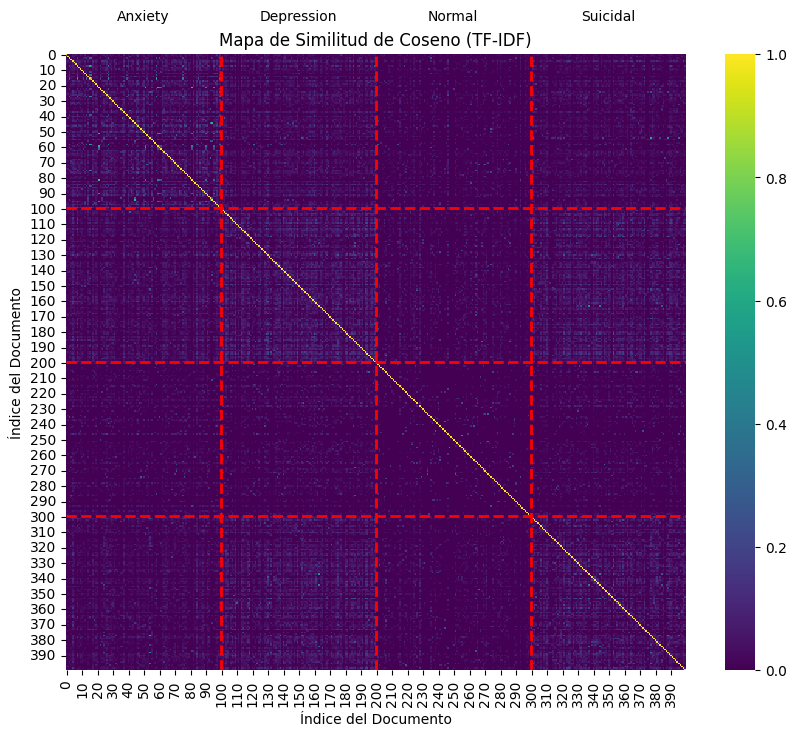

Pares de documentos más similares (Índices):
Docs 21 y 81 -> Similitud: 0.6918
Categorías: Anxiety vs Anxiety

Docs 15 y 16 -> Similitud: 0.7045
Categorías: Anxiety vs Anxiety

Docs 16 y 15 -> Similitud: 0.7045
Categorías: Anxiety vs Anxiety



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Función para encontrar los pares de documentos más y menos similares
def identificar_pares(matriz_sim, n_pares=3):
    m = matriz_sim.copy()
    np.fill_diagonal(m, 0)

    # Encontramos los índices de los n_pares más similares
    # np.argsort devuelve los índices que ordenarían la matriz
    # np.unravel_index convierte un índice plano en coordenadas de fila y columna
    idx_max_flat = np.argsort(m, axis=None)[-n_pares:]
    idx_max = np.unravel_index(idx_max_flat, m.shape)

    # Encontramos los índices de los n_pares menos similares
    idx_min_flat = np.argsort(m, axis=None)[:n_pares]
    idx_min = np.unravel_index(idx_min_flat, m.shape)
    return idx_max, idx_min

df_sample = df.groupby('status', group_keys=False).sample(100, random_state=42).reset_index(drop=True)
vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(df_sample['text_no_stops'])

sim_tfidf = cosine_similarity(X_tfidf)
max_idx, _ = identificar_pares(sim_tfidf)

print("Ejercicio 6: Similitud entre Documentos \n")

# 1. Visualizar la similitud con un mapa de calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(sim_tfidf, cmap='viridis')
plt.title('Mapa de Similitud de Coseno (TF-IDF)')
# se usa el de TF IDF porque es el más detallado
plt.xlabel('Índice del Documento')
plt.ylabel('Índice del Documento')

# lineas para separar cada clase (400 en total, 100 por clase)
class_boundaries = [100, 200, 300]
for boundary in class_boundaries:
    plt.axhline(y=boundary, color='red', linestyle='--', linewidth=2)
    plt.axvline(x=boundary, color='red', linestyle='--', linewidth=2)

#identificar las clases
plt.text(50, -20, 'Anxiety', color='black', ha='center', va='bottom', fontsize=10)
plt.text(150, -20, 'Depression', color='black', ha='center', va='bottom', fontsize=10)
plt.text(250, -20, 'Normal', color='black', ha='center', va='bottom', fontsize=10)
plt.text(350, -20, 'Suicidal', color='black', ha='center', va='bottom', fontsize=10)

plt.show()

# 2. Mostrar los pares más similares encontrados por tu función
print("Pares de documentos más similares (Índices):")
for i in range(len(max_idx[0])):
    doc1 = max_idx[0][i]
    doc2 = max_idx[1][i]
    sim_val = sim_tfidf[doc1, doc2]
    print(f"Docs {doc1} y {doc2} -> Similitud: {sim_val:.4f}")
    print(f"Categorías: {df_sample.iloc[doc1]['status']} vs {df_sample.iloc[doc2]['status']}\n")

## Finalmente, comentar:

### • ¿Qué factores podrían explicar que ciertos documentos sean más similares entre sí?

Los documentos tienden a ser más similares entre sí cuando comparten un contenido léxico significativo. Los principales factores son: La pertenencia a la misma clase, como observamos en los resultados, los pares de documentos más similares pertenecen casi siempre a la misma categoría. Esto se debe a que las personas que expresan un mismo estado de salud mental suelen utilizar vocabulario, frases y conceptos relacionados que capturan ese estado. Otro factor es la temática, lod documentos que abordan el mismo tema específico o expresan emociones similares, incluso dentro de la misma clase, mostrarán alta similitud. Y finalmente, la repetición de palabras clave, la simple frecuencia de ciertas palabras, especialmente en los modelos Bag of Words, puede aumentar la similitud, aunque TF-IDF disminuye esto ponderando la importancia de la palabra.

### • ¿Qué diferencias aparecen al usar TF-IDF en lugar de BoW o booleano?

Las diferencias clave radican en cómo ponderan y representan la importancia de las palabras en TF-IDF, no solo considera cuántas veces aparece una palabra en un documento, sino también cuán única es esa palabra en todo el corpus. Las palabras comunes en muchos documentos (como los artículos y preposiciones) reciben un peso bajo, mientras que las palabras que son frecuentes en un documento específico pero raras en el corpus (términos distintivos) reciben un peso alto. Esto lo hace muy efectivo para capturar la relevancia semántica y distinguir documentos por su contenido único. Ahora bien, en bag of words se representa los documentos basándose únicamente en la frecuencia con la que aparece cada palabra, sin considerar su orden. Es directo y capta la cantidad de veces que se usan ciertas palabras. Tiende a otorgar alta similitud a documentos con muchas palabras en común, pero puede dar demasiada importancia a palabras frecuentes que no son necesariamente distintivas del tema. Y en el modelo booleano, el cual es el más simple, registrando solo la presencia (1) o ausencia (0) de una palabra en un documento, sin importar su frecuencia. Esto significa que si una palabra aparece una vez o veinte veces, el valor es el mismo. Pierde toda la información sobre la intensidad o repetición, lo que puede ser una limitación si la frecuencia es un indicador importante.

En resumen, TF-IDF prioriza la relevancia semántica, BoW se enfoca en la frecuencia de las palabras, y el modelo Booleano en la mera existencia de las palabras.

### • ¿Cuál representación considera más útil para este problema y por qué?

Para este problema de clasificación de estados de salud mental, la representación **TF-IDF** se considera la más útil. Porque enfatisa términos distintivos, el TF-IDF es excelente para identificar palabras que son realmente características de una clase específica (como 'depression', 'suicidal', 'anxiety'). Al dar mayor peso a estas palabras que son frecuentes en un documento de una clase pero raras en el resto del corpus, ayuda a que el modelo capture la 'firma léxica' de cada condición. Además, reduce el ruido al disminuir la importancia de palabras repetitivas o comunes, pero que no aportan a la distinción de categorias. Y mejora el rendimiento en tareas de clasificación, ya que proporciona una representación más informativa y ponderada de los documentos, lo que permite a los algoritmos distinguir mejor entre las diferentes clases.

## Comentario

Buen trabajo! muy completo el análisis.

### Puntaje ej6: 1.90

##Ejercicio 7: Discusión
Con todo lo implementado comente ¿Qué conclusiones generales podemos extraer del
dataset trabajado?

## Conclusiones Generales del Dataset


1.  Desbalance de Clases Significativo: El dataset presenta un marcado desbalance en las clases de 'status', con 'Normal' siendo la categoría predominante y 'Anxiety' la minoritaria. Este desbalance es crucial y debe ser abordado para evitar sesgos y asegurar que los modelos sean capaces de identificar correctamente las clases minoritarias.

2.  Importancia del Preprocesamiento de Texto: Las etapas de limpieza, tokenización, eliminación de stopwords y lematización resultaron ser fundamentales. La lematización, en particular, demostró ser una elección acertada al preservar el significado semántico de las palabras, lo cual es vital para comprender los matices en el lenguaje relacionado con la salud mental.

3.  Patrones Léxicos Distintivos por Estado Mental: El análisis léxico por clase reveló que cada estado mental se asocia con un vocabulario particular. Las clases relacionadas con la salud mental (Depression, Suicidal, Anxiety) utilizan términos más específicos y cargados emocionalmente, mientras que la clase 'Normal' muestra una mayor diversidad léxica y términos más genéricos. Esto subraya el potencial del análisis textual para diferenciar entre los distintos estados.

4.  TF-IDF como Representación Vectorial Superior: La comparación de los modelos de representación vectorial (Bag of Words, Booleano, TF-IDF) sugiere que TF-IDF es el más adecuado para este Dataset. Su capacidad para ponderar la relevancia de las palabras, dando mayor peso a términos distintivos y menor a palabras comunes, lo hace más efectivo para capturar la 'firma léxica' de cada condición y para la posterior clasificación.

5.  Coherencia Temática dentro de las Clases: El análisis de similitud de coseno confirmó que los documentos más similares tienden a pertenecer a la misma clase. Esto indica que las representaciones vectoriales son efectivas para agrupar textos con temáticas y sentimientos afines, lo que valida la calidad de la información extraída y su utilidad para tareas de clasificación.



## Comentario

Buen análisis final.

### Puntaje ej7: 1.0

## Puntaje final: 0.8+1+1.20+1.30+1.50+1.90+1 +1 base = 9.7

# Nota: 6.8